# House Prices Contest

## Imports:

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlflow.metrics import r2_score

## Connect to DagsHub

In [65]:
from dagshub.data_engine.datasources import mlflow
import dagshub

dagshub.init(repo_owner="NikaMikeltadze", repo_name="assignment_1_nmike23", mlflow=True)

mlflow.set_experiment('house-prices-contest')

print('Setup complete')

Initialized MLflow to track repo "NikaMikeltadze/assignment_1_nmike23"

Repository NikaMikeltadze/assignment_1_nmike23 initialized!

Setup complete


## Load Data

In [66]:
train_data = pd.read_csv('data/train.csv')
test_data = pd.read_csv('data/test.csv')

# Drop extreme outliers
train_data = train_data.drop(train_data[(train_data['GrLivArea'] > 4000) & (train_data['SalePrice'] < 300000)].index).reset_index(drop=True)

train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Visualise Data

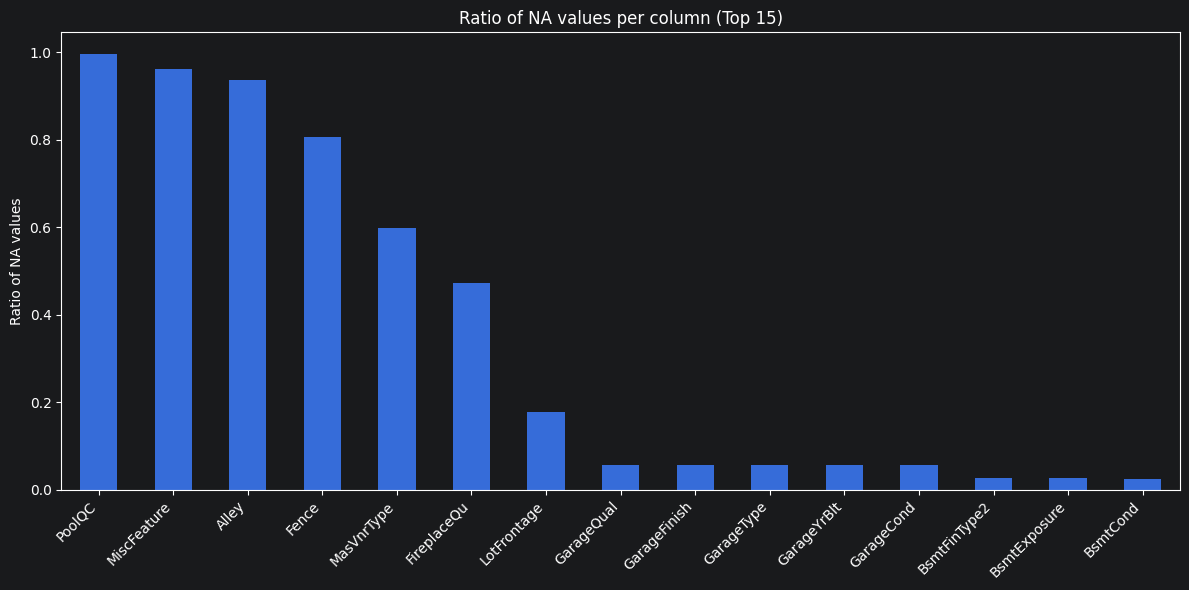

In [67]:
null_ratio = train_data.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
null_ratio.head(15).plot(kind='bar')
plt.title('Ratio of NA values per column (Top 15)')
plt.ylabel('Ratio of NA values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

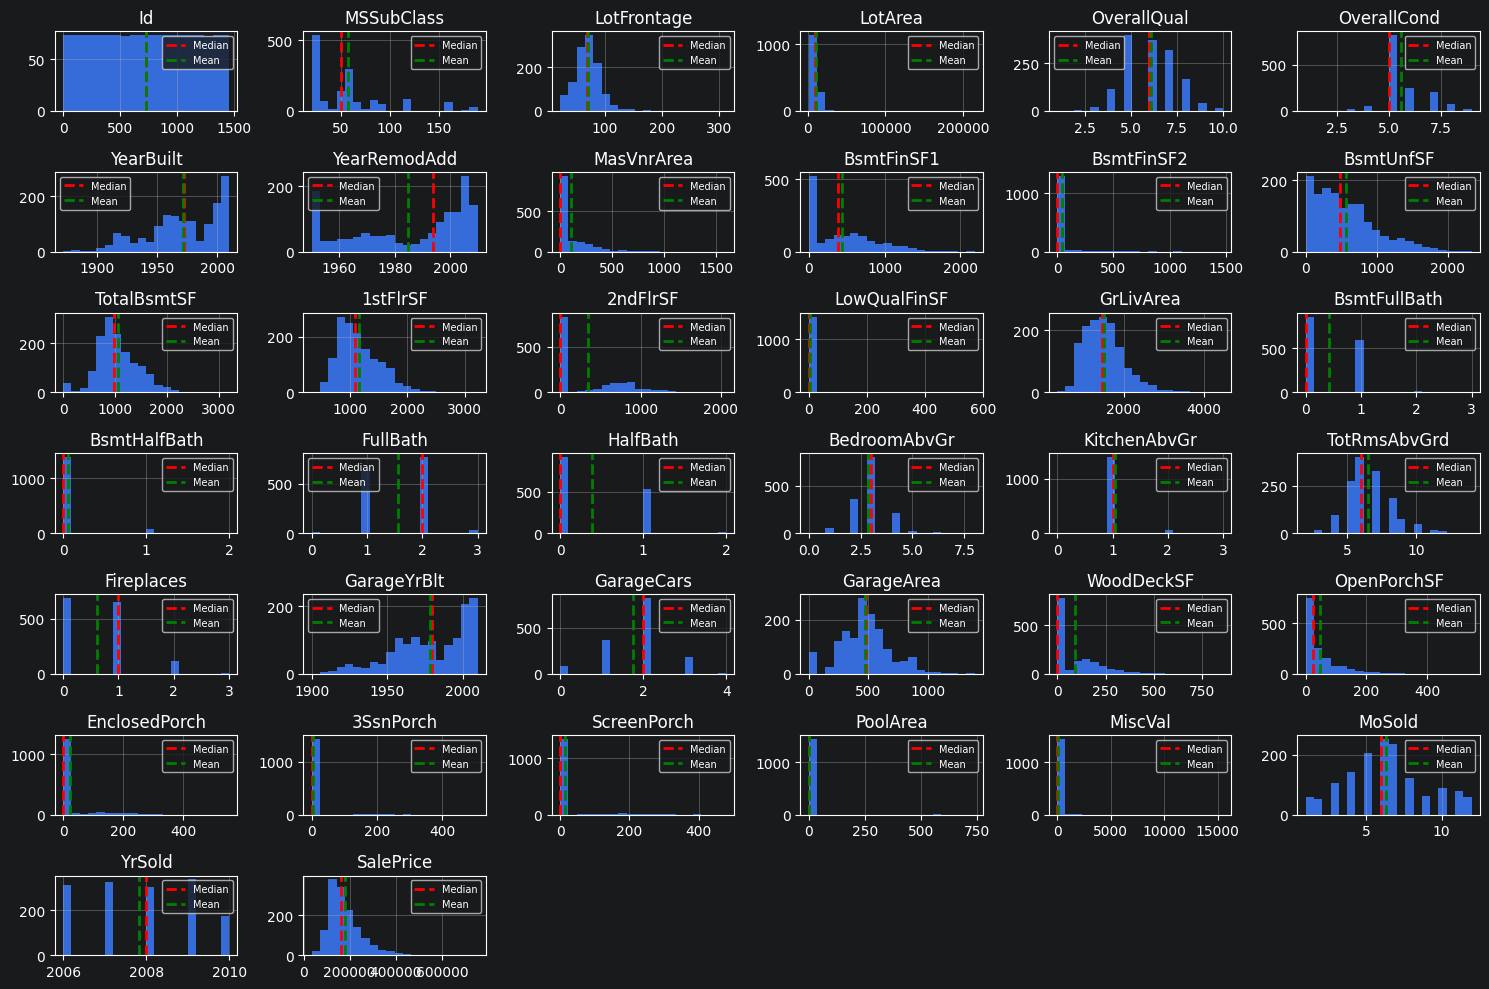

In [68]:
type_numeric_cols = train_data.select_dtypes(include=[np.number]).columns
train_data[type_numeric_cols].describe()

plt.figure(figsize=(15, 10))
axes = train_data[type_numeric_cols].hist(bins=20, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(type_numeric_cols):
    median_val = train_data[col].median()
    mean_val = train_data[col].mean()

    axes[idx].axvline(median_val, color='red', linestyle='--', linewidth=2, label='Median')
    axes[idx].axvline(mean_val, color='green', linestyle='--', linewidth=2, label='Mean')
    axes[idx].legend(fontsize=7)

plt.tight_layout()
plt.show()

## Cleaning

### Drop columns id and columns with (>40%) NA values

In [69]:
train_data = train_data.drop(columns=['Id'])

In [70]:
na_stat = train_data.isna().mean().sort_values(ascending=False)

In [71]:
na_rm_cols = na_stat[na_stat > 0.4].index
train_data = train_data.drop(columns=na_rm_cols, errors='ignore')

In [72]:
na_rm_cols

Index(['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu'], dtype='object')

In [73]:
train_data

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2007,WD,Normal,175000
1454,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2010,WD,Normal,210000
1455,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1456,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,112,0,0,0,0,4,2010,WD,Normal,142125


### Fill NA values (categorical and numerical)

In [74]:
not_present_cols = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                    'FireplaceQu', 'GarageType', 'GarageFinish',
                    'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType']

for col in not_present_cols:
    if col in train_data.columns:
        train_data[col] = train_data[col].fillna('NP')  # Not Present
    if col in test_data.columns:
        test_data[col] = test_data[col].fillna('NP')

quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NP': 0}

quality_numeric_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
]
for col in quality_numeric_cols:
    if col in train_data.columns:
        train_data[col] = train_data[col].fillna('NP').map(quality_map)
    if col in test_data.columns:
        test_data[col] = test_data[col].fillna('NP').map(quality_map)

In [75]:
type_numeric_cols = train_data.select_dtypes(include=[np.number]).columns

for col in type_numeric_cols:
    train_data[col] = train_data[col].fillna(train_data[col].median())
    if col in test_data.columns:
        test_data[col] = test_data[col].fillna(train_data[col].median())

In [76]:
type_category_cols = train_data.select_dtypes(include=['object']).columns

for col in type_category_cols:
    train_data[col] = train_data[col].fillna(train_data[col].mode()[0])
    if col in test_data.columns:
        test_data[col] = test_data[col].fillna(train_data[col].mode()[0])

In [77]:
print(f'NA data val count: {train_data.isna().sum().sum()}')

NA data val count: 0


## Feature Engineering

In [78]:
#Combine total square feet column
train_data['TotalSF'] = train_data['TotalBsmtSF'] + train_data['1stFlrSF'] + train_data['2ndFlrSF']
test_data['TotalSF'] = test_data['TotalBsmtSF'] + test_data['1stFlrSF'] + test_data['2ndFlrSF']

In [79]:
# Total living area
train_data['TotalLivingSF'] = train_data['GrLivArea'] + train_data['TotalBsmtSF']
test_data['TotalLivingSF'] = test_data['GrLivArea'] + test_data['TotalBsmtSF']

In [80]:
# Total bathrooms
train_data['TotalBathrooms'] = (train_data['FullBath']
                                + (0.5 * train_data['HalfBath'])
                                + train_data['BsmtFullBath']
                                + (0.5 * train_data['BsmtHalfBath']))
test_data['TotalBathrooms'] = (test_data['FullBath']
                               + (0.5 * test_data['HalfBath'])
                               + test_data['BsmtFullBath']
                               + (0.5 * test_data['BsmtHalfBath']))

In [81]:
# Room Ratios
train_data['BedroomRatio'] = train_data['BedroomAbvGr'] / (train_data['TotRmsAbvGrd'])
train_data['KitchenRatio'] = train_data['KitchenAbvGr'] / (train_data['TotRmsAbvGrd'])
train_data['RoomRatio'] = train_data['TotRmsAbvGrd'] / (train_data['TotalSF'])

test_data['BedroomRatio'] = test_data['BedroomAbvGr'] / (test_data['TotRmsAbvGrd'])
test_data['KitchenRatio'] = test_data['KitchenAbvGr'] / (test_data['TotRmsAbvGrd'])
test_data['RoomRatio'] = test_data['TotRmsAbvGrd'] / (test_data['TotalSF'])

In [82]:
# House 'age'
train_data['HouseAge'] = train_data['YrSold'] - train_data['YearBuilt']
train_data['RemodAge'] = train_data['YrSold'] - train_data['YearRemodAdd']
train_data['WasRemodeled'] = (train_data['YearRemodAdd'] != train_data['YearBuilt']).astype(int)

test_data['HouseAge'] = test_data['YrSold'] - test_data['YearBuilt']
test_data['RemodAge'] = test_data['YrSold'] - test_data['YearRemodAdd']
test_data['WasRemodeled'] = (test_data['YearRemodAdd'] != test_data['YearBuilt']).astype(int)

In [83]:
# Extras
train_data['HasPool'] = (train_data['PoolArea'] > 0).astype(int)
train_data['HasGarage'] = (train_data['GarageArea'] > 0).astype(int)
train_data['HasFireplace'] = (train_data['Fireplaces'] > 0).astype(int)
train_data['HasBasement'] = (train_data['TotalBsmtSF'] > 0).astype(int)

test_data['HasPool'] = (test_data['PoolArea'] > 0).astype(int)
test_data['HasGarage'] = (test_data['GarageArea'] > 0).astype(int)
test_data['HasFireplace'] = (test_data['Fireplaces'] > 0).astype(int)
test_data['HasBasement'] = (test_data['TotalBsmtSF'] > 0).astype(int)

In [84]:
# Quality Score
train_data['QualityScore'] = train_data['OverallQual'] * train_data['OverallCond'] * train_data['TotalSF']
test_data['QualityScore'] = test_data['OverallQual'] * test_data['OverallCond'] * test_data['TotalSF']

# Garage
train_data['GarageQualityScore'] = train_data['GarageQual'] * train_data['GarageCond'] * train_data['GarageArea']
test_data['GarageQualityScore'] = test_data['GarageQual'] * test_data['GarageCond'] * test_data['GarageArea']

## Visualize Feature Skewness

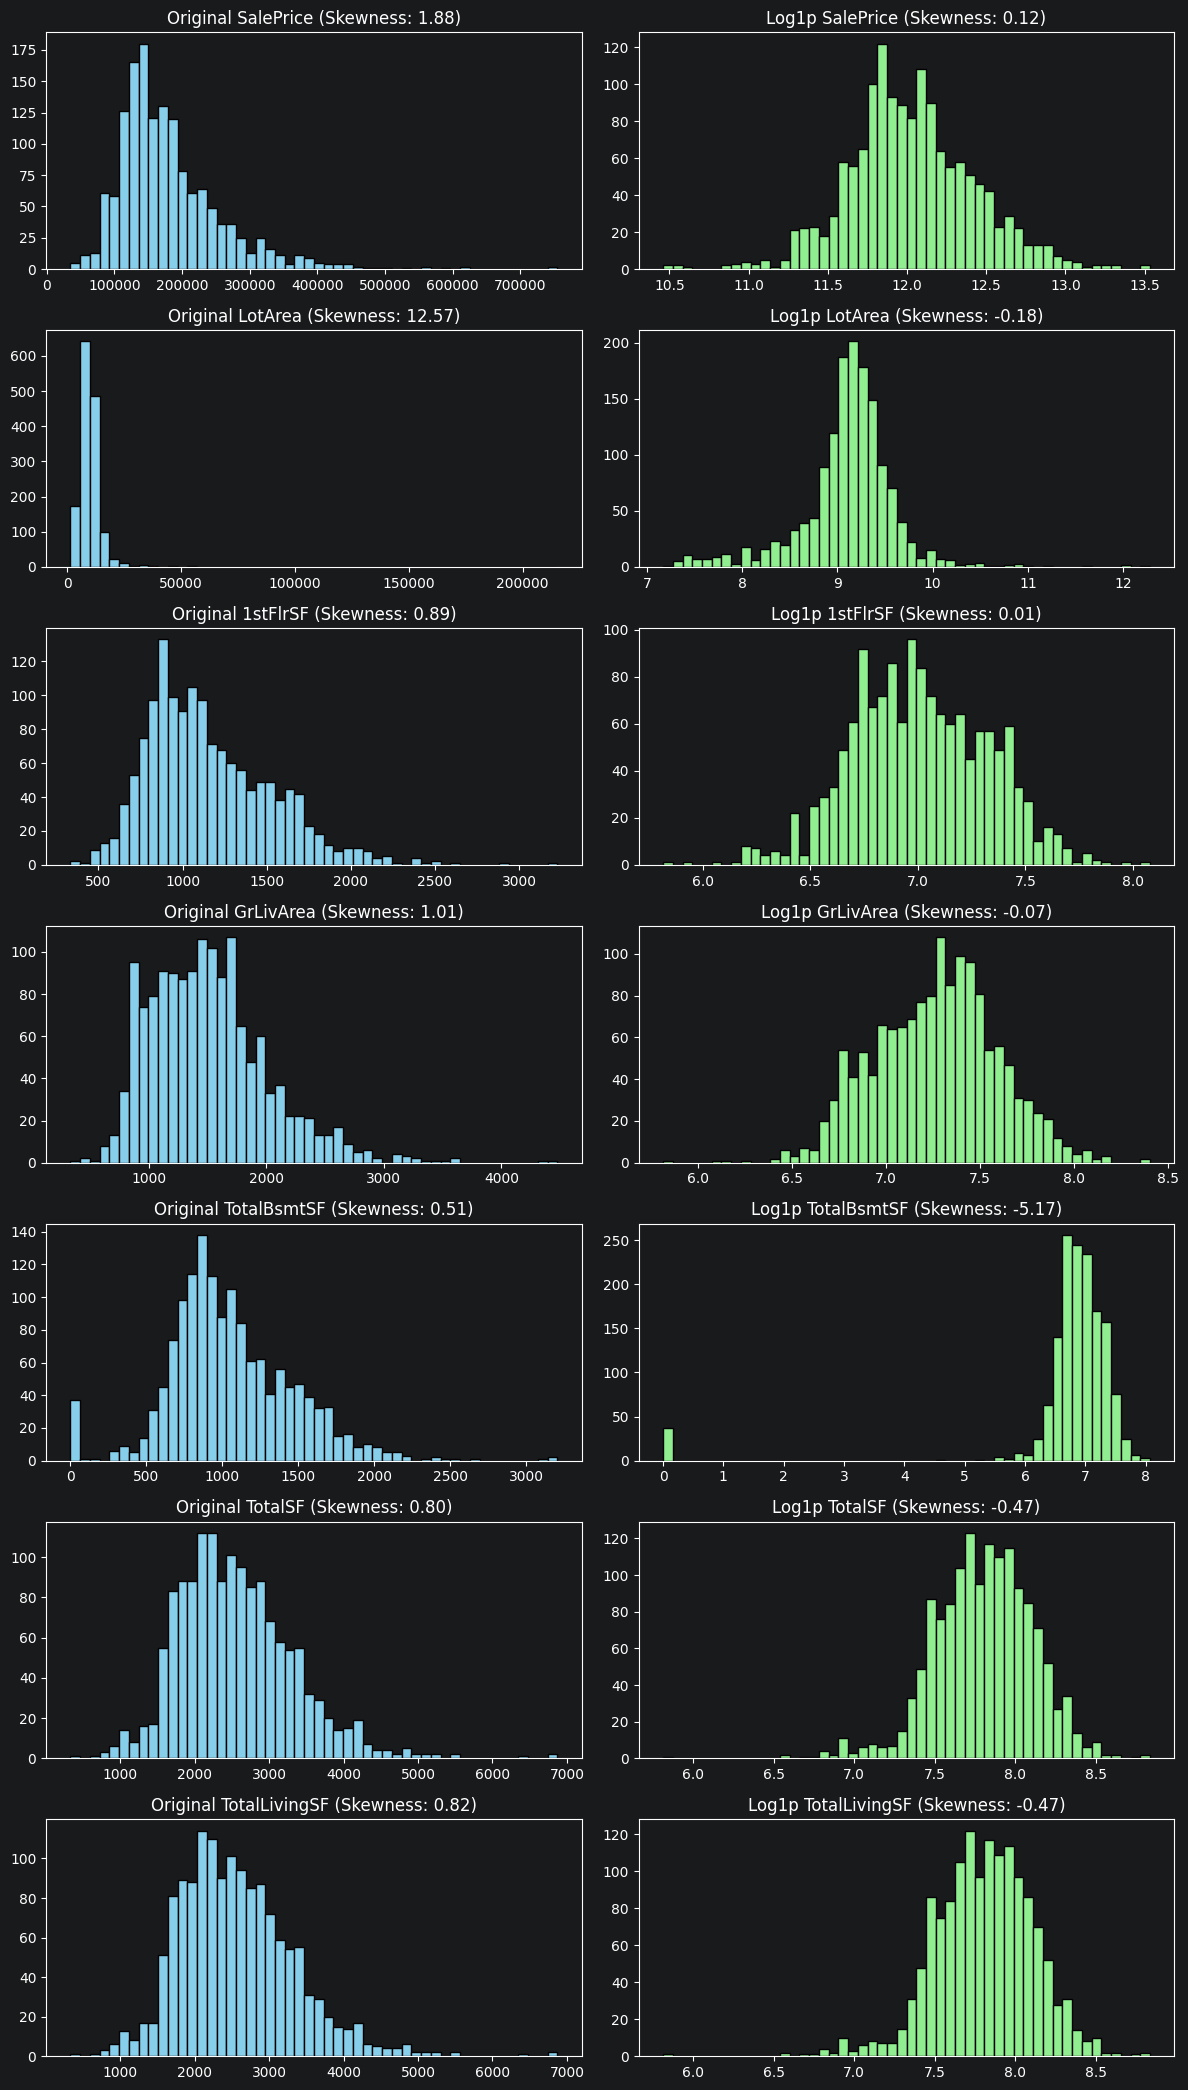

In [85]:
skewed_cols_to_plot = ['SalePrice', 'LotArea', '1stFlrSF', 'GrLivArea', 'TotalBsmtSF', 'TotalSF', 'TotalLivingSF']
fig, axes = plt.subplots(len(skewed_cols_to_plot), 2, figsize=(12, 3 * len(skewed_cols_to_plot)))

for i, col in enumerate(skewed_cols_to_plot):
    if col in train_data.columns:
        orig_data = train_data[col].dropna()
        axes[i, 0].hist(orig_data, bins=50, color='skyblue', edgecolor='black')
        axes[i, 0].set_title(f'Original {col} (Skewness: {orig_data.skew():.2f})')

        log_data = np.log1p(orig_data)
        axes[i, 1].hist(log_data, bins=50, color='lightgreen', edgecolor='black')
        axes[i, 1].set_title(f'Log1p {col} (Skewness: {log_data.skew():.2f})')

plt.tight_layout()
plt.show()

## Prep Data for Modeling

In [86]:
X_train = train_data.drop(columns=['SalePrice'])
# Apply log transformation to target
Y_train = np.log1p(train_data['SalePrice'])

# Apply log transformation to highly skewed continuous features
skewed_cols = ['LotArea', '1stFlrSF', 'GrLivArea', 'TotalBsmtSF', 'TotalSF', 'TotalLivingSF']
for col in skewed_cols:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
    if col in test_data.columns:
        test_data[col] = np.log1p(test_data[col])

In [87]:
categorical_cols = X_train.select_dtypes(include=['object']).columns
numerical_cols = X_train.select_dtypes(include=[np.number]).columns

In [88]:
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(test_data.drop(columns=['Id']), columns=categorical_cols, drop_first=True)

In [89]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
print(set(X_train.columns) == set(X_test.columns))

True


## Feature Selection

In [90]:
# Drop highly correlated columns
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print(f'Dropping features with > 0.85 correlation: {len(to_drop)} features')

X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)


Dropping features with > 0.85 correlation: 25 features


In [91]:
# 2. Drop columns with |very low| correlation to the target
X_train_temp = X_train.copy()
X_train_temp['SalePrice'] = Y_train
target_corr = X_train_temp.corr()['SalePrice'].abs()

low_corr_features = target_corr[target_corr < 0.05].index.tolist()
low_corr_features = [f for f in low_corr_features if f != 'SalePrice' and f in X_train.columns]
print(f'Dropping features with < 0.05 correlation to SalePrice: {len(low_corr_features)} features')

X_train = X_train.drop(columns=low_corr_features)
X_test = X_test.drop(columns=low_corr_features)


Dropping features with < 0.05 correlation to SalePrice: 69 features


## Model Training Pipeline

In [92]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

rf_model = Pipeline([
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])
dt_model = Pipeline([
    ('model', DecisionTreeRegressor(random_state=42))
])

In [93]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def run_experiment(experiment_name, pipeline, X_train, X_test, y_train, y_test, params=None):
    with mlflow.start_run(run_name=experiment_name):
        if params:
            mlflow.log_params(params)

        pipeline.fit(X_train, y_train)

        # Validation Predictions
        val_predictions_log = pipeline.predict(X_test)
        val_predictions = np.expm1(val_predictions_log)
        y_test_orig = np.expm1(y_test)

        # Train Predictions
        train_predictions_log = pipeline.predict(X_train)
        train_predictions = np.expm1(train_predictions_log)
        y_train_orig = np.expm1(y_train)

        # Validation Metrics (RMSLE is RMSE on log scale)
        val_rmse = np.sqrt(mean_squared_error(y_test, val_predictions_log))
        val_mae = mean_absolute_error(y_test_orig, val_predictions)
        val_r2 = r2_score(y_test, val_predictions_log)

        # Train Metrics
        train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions_log))
        train_mae = mean_absolute_error(y_train_orig, train_predictions)
        train_r2 = r2_score(y_train, train_predictions_log)

        # Log model and metrics
        mlflow.sklearn.log_model(pipeline,
                                 name=experiment_name,
                                 registered_model_name=f'HousePrices_{experiment_name}')

        mlflow.log_metrics({
            'train_rmse': train_rmse,
            'train_mae': train_mae,
            'train_r2': train_r2,
            'val_rmse': val_rmse,
            'val_mae': val_mae,
            'val_r2': val_r2
        })



In [94]:
from sklearn.model_selection import train_test_split

X_train_local, X_val_local, Y_train_local, Y_val_local = train_test_split(
    X_train, Y_train,
    test_size=0.2, random_state=42)

run_experiment('LinearRegression', linear_model, X_train_local, X_val_local, Y_train_local, Y_val_local)
run_experiment('RandomForestRegressor', rf_model, X_train_local, X_val_local, Y_train_local, Y_val_local, params={'n_estimators': 100})

# 1. Underfitted Model (Too simple, low Train R2, low Val R2)
dt_underfit = Pipeline([('model', DecisionTreeRegressor(max_depth=1, random_state=42))])
run_experiment('DecisionTree_Underfitted', dt_underfit,
               X_train_local, X_val_local, Y_train_local, Y_val_local,
               params={'max_depth': 1})

# 2. OverFitted Model (Too complex, perfect Train R2, worse Val R2)
dt_overfit = Pipeline([('model', DecisionTreeRegressor(max_depth=None, min_samples_split=2, random_state=42))])
run_experiment('DecisionTree_Overfitted', dt_overfit,
               X_train_local, X_val_local, Y_train_local, Y_val_local,
               params={'max_depth': None, 'min_samples_split': 2})

# 3. Balanced Model (Ideally found via GridSearch)
dt_balanced = Pipeline([('model', DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42))])
run_experiment('DecisionTree_Balanced', dt_balanced,
               X_train_local, X_val_local, Y_train_local, Y_val_local,
               params={'max_depth': 5, 'min_samples_split': 10})


2026/04/08 19:10:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'HousePrices_LinearRegression' already exists. Creating a new version of this model...
2026/04/08 19:10:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_LinearRegression, version 9
Created version '9' of model 'HousePrices_LinearRegression'.


🏃 View run LinearRegression at: https://dagshub.com/NikaMikeltadze/assignment_1_nmike23.mlflow/#/experiments/0/runs/6fb5e7d529574687ad7483df8cb70579
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/assignment_1_nmike23.mlflow/#/experiments/0


2026/04/08 19:10:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'HousePrices_RandomForestRegressor' already exists. Creating a new version of this model...
2026/04/08 19:11:17 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_RandomForestRegressor, version 8
Created version '8' of model 'HousePrices_RandomForestRegressor'.


🏃 View run RandomForestRegressor at: https://dagshub.com/NikaMikeltadze/assignment_1_nmike23.mlflow/#/experiments/0/runs/11e90248b14249a6ab293f3269ba0cac
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/assignment_1_nmike23.mlflow/#/experiments/0


2026/04/08 19:11:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'HousePrices_DecisionTree_Underfitted' already exists. Creating a new version of this model...
2026/04/08 19:11:31 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_DecisionTree_Underfitted, version 6
Created version '6' of model 'HousePrices_DecisionTree_Underfitted'.


🏃 View run DecisionTree_Underfitted at: https://dagshub.com/NikaMikeltadze/assignment_1_nmike23.mlflow/#/experiments/0/runs/7a205a7c9781462f8fafee26cb1c71fb
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/assignment_1_nmike23.mlflow/#/experiments/0


2026/04/08 19:11:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'HousePrices_DecisionTree_Overfitted' already exists. Creating a new version of this model...
2026/04/08 19:11:52 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_DecisionTree_Overfitted, version 6
Created version '6' of model 'HousePrices_DecisionTree_Overfitted'.


🏃 View run DecisionTree_Overfitted at: https://dagshub.com/NikaMikeltadze/assignment_1_nmike23.mlflow/#/experiments/0/runs/14472583a94c4811a4f9f56bf44fcf7f
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/assignment_1_nmike23.mlflow/#/experiments/0


2026/04/08 19:12:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'HousePrices_DecisionTree_Balanced' already exists. Creating a new version of this model...
2026/04/08 19:12:13 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_DecisionTree_Balanced, version 6
Created version '6' of model 'HousePrices_DecisionTree_Balanced'.


🏃 View run DecisionTree_Balanced at: https://dagshub.com/NikaMikeltadze/assignment_1_nmike23.mlflow/#/experiments/0/runs/a1b0b859b0ab4fd5bccae3d3eb0f92dd
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/assignment_1_nmike23.mlflow/#/experiments/0


### Hyperparameter Optimization (Grid Search)

In [95]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# Test different hyperparameters for RandomForest model
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5, 10]
}

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

grid_search = GridSearchCV(estimator=rf_pipeline, param_grid=param_grid,
                           cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train_local, Y_train_local)

best_params = grid_search.best_params_
print(f"Best parameters found: {best_params}")

# Run optimal model experiment
run_experiment('RandomForest_Optimized', grid_search.best_estimator_,
               X_train_local, X_val_local, Y_train_local, Y_val_local,
               params=best_params)

# _____________
# Decision Tree
dt_param_grid = {
    'model__max_depth': [3, 5, 10, 20, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 5]
}
dt_pipeline = Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeRegressor(random_state=42))])

dt_grid = GridSearchCV(dt_pipeline, dt_param_grid, cv=3, scoring='r2', n_jobs=-1)
dt_grid.fit(X_train_local, Y_train_local)

run_experiment('DecisionTree_Optimized', dt_grid.best_estimator_,
               X_train_local, X_val_local, Y_train_local, Y_val_local,
               params=dt_grid.best_params_)

# _______
# Linear Model
ridge_param_grid = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}
ridge_pipeline = Pipeline([('scaler', StandardScaler()), ('model', Ridge(random_state=42))])

ridge_grid = GridSearchCV(ridge_pipeline, ridge_param_grid, cv=3, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train_local, Y_train_local)

run_experiment('Ridge_Optimized', ridge_grid.best_estimator_,
               X_train_local, X_val_local, Y_train_local, Y_val_local,
               params=ridge_grid.best_params_)

Best parameters found: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 50}


2026/04/08 19:12:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'HousePrices_RandomForest_Optimized' already exists. Creating a new version of this model...
2026/04/08 19:13:07 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_RandomForest_Optimized, version 6
Created version '6' of model 'HousePrices_RandomForest_Optimized'.


🏃 View run RandomForest_Optimized at: https://dagshub.com/NikaMikeltadze/assignment_1_nmike23.mlflow/#/experiments/0/runs/c7ae5ee7b93e496bb54bbc9674fccc6c
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/assignment_1_nmike23.mlflow/#/experiments/0


2026/04/08 19:13:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'HousePrices_DecisionTree_Optimized' already exists. Creating a new version of this model...
2026/04/08 19:13:21 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_DecisionTree_Optimized, version 6
Created version '6' of model 'HousePrices_DecisionTree_Optimized'.


🏃 View run DecisionTree_Optimized at: https://dagshub.com/NikaMikeltadze/assignment_1_nmike23.mlflow/#/experiments/0/runs/0dd9f9821d8f4a40b7b356944ab260c2
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/assignment_1_nmike23.mlflow/#/experiments/0


2026/04/08 19:13:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'HousePrices_Ridge_Optimized' already exists. Creating a new version of this model...
2026/04/08 19:13:42 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_Ridge_Optimized, version 6
Created version '6' of model 'HousePrices_Ridge_Optimized'.


🏃 View run Ridge_Optimized at: https://dagshub.com/NikaMikeltadze/assignment_1_nmike23.mlflow/#/experiments/0/runs/a70275a7cb634a4ab4553e3bf464e101
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/assignment_1_nmike23.mlflow/#/experiments/0
